# Estudio de métodos aproximados para el aprendizaje por refuerzo en entornos continuos

## Introducción

## Preparación del entorno

In [1]:
# Librerías necesarias para el setup
import sys, os

En función de si el notebook se va a ejecutar en Colab o en local, dentro del repositorio clonado, se deberá ejecutar una de las dos siguientes secciones. 

### Ejecución en Colab

In [2]:
# Clonar el repositorio

In [3]:
# Añadir los directorio fuentes al path de Python

### Ejecución en local

In [4]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv', '', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv\\Lib\\site-packages', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\entornos_complejos\\src']


### Importación de librerías y módulos

In [ ]:
import gymnasium as gym
import numpy as np

from agents import Agent
from utils import TileCodingEnv, make_tile_feature_fn, run_episode_greedy, frames_to_gif
from policies import EpsilonGreedyPolicy
from learners import SARSASemiGradient, DQNLearner, QNetwork, DoubleDQNLearner
from plotting import plotting
import matplotlib.pyplot as plt

## Entorno de Gymnasium

Notas:

Debe ser un entorno cuyo espacio de observaciones sea **continuo**. Una opción podría ser el entorno [*Cart Pole*](https://gymnasium.farama.org/environments/classic_control/cart_pole/), pero hay que tener cuidado al discretizarlo para SARSA semi-gradiente porque las velocidades lineal y angular no están acotadas (van de -inf a +inf), así que imagino que tendremos que elegir nosotros un valor mínimo y máximo apropiado. En [este](https://github.com/ldaniel-hm/eml_approximate/blob/main/SolucionDeepSARSA_CartPole.ipynb) notebook se indica como generar una animación del Cart Pole.

En cuanto a las formas de discretizar, podemos empezar por el tile coding porque ya está implementado en el [notebook del profesor](https://github.com/ldaniel-hm/eml_approximate/blob/main/Dos_formas_de_discretizar_espacios_continuos.ipynb), pero quizás estaría bien posteriormente probar con otros métodos de discretización que se comentan en el power point de "Predicción On Policy con Aproximaciones" (Fourier, codificación gruesa, etc.).

Para implementar el discretizador, como se dice en el notebook del profesor, habría que crear una clase que herede de gym.ObservationWrapper. Podríamos hacer un nuevo módulo para meter ahí los discretizadores, en caso de que hagamos varios.

En cuanto a Deep Q-Learning, además de probar con el método estándar, podríamos implementar también Doble Deep Q-Learning y compararlos.

Es posible que en estos nuevos Learners haya que incluir una property ``qtable`` para poder usar la misma clase Agent sin tener que modificarla. Lo ideal sería adaptar estas nuevas clases para hacer el mínimo número de cambios posible. 

:)

In [7]:
env = gym.make("CartPole-v1")
env = gym.wrappers.TimeLimit(env, max_episode_steps=1000)
state_size = 4 # CartPole: 4 variables de estado.
action_size = env.action_space.n  # CartPole: 2 acciones posibles.
env.reset()

(array([-0.04468918, -0.03981874, -0.03737599, -0.03136791], dtype=float32),
 {})

## Entrenamientos

### Parámetros comunes

In [8]:
gamma = 0.95 # Tasa de descuento (importancia que el agente proporciona a futuras recompensas)
n_steps = 5 # Para diferencias temporales de n pasos
num_episodes = 400 # Nº de episodios por ejecución
n_runs = 10 # Nº de ejecuciones (los resultados serán la media de ellas)
SEED = 123 # Reproducibilidad

policy = EpsilonGreedyPolicy(epsilon=0.1)

### Parámetros específicos

#### SARSA-Semigradient

In [9]:
n_tilings = 4
bins = np.array([8, 8, 8, 8])
low = np.array([-4.8, -3.0, -0.418, -3.0])
high = np.array([ 4.8,  3.0,  0.418,  3.0])

env = gym.make("CartPole-v1")
env_sarsa = TileCodingEnv(env, bins=bins, low=low, high=high, n=n_tilings)

n_actions = env_sarsa.action_space.n # 2

In [10]:
alpha_sarsa = 0.1 / n_tilings # learning rate, al usar 4 tilings dividimos el valor original entre la cantidad de tilings

In [11]:
feature_fn, state_size_sarsa = make_tile_feature_fn(
    bins = bins,
    n_tilings = n_tilings,
    n_actions = n_actions
) # Función x(s, a)

#### Deep Q Learning & Double Deep Q Learning

In [12]:
state_size_dql = 4  # CartPole: 4 variables de estado.
q_network = QNetwork(state_dim=state_size_dql, action_dim=n_actions, hidden_dim=64) # instancia de QNetwork
alpha_q_network = 1e-3 # tasa de aprendizaje del optimizador
memory_size = 10_000 # capacidad N de la replay memory
batch_size = 64 # tamaño del minibatch para cada paso de gradiente
min_memory = None # mínimo de transiciones en D antes de empezar a entrenar
target_update_freq = 100 #cada cuantos pasos se sincronizan los pesos de la red target con los de la red online (exclusivo de double deep q learning)

### Ejecuciones

In [14]:
learner_sarsasemigradient = SARSASemiGradient(
    state_size = state_size_sarsa, # 4 x 4096 x 2 = 32768
    action_size = n_actions,
    alpha = alpha_sarsa, # escalar alpha por n_tilings
    gamma = 0.99,
    policy = policy,
    feature_fn = feature_fn
)

learner_deepqlearning = DQNLearner(
    state_size=state_size_dql,
    action_size=n_actions,
    q_network=q_network,
    alpha=alpha_q_network,
    gamma=gamma,
    memory_size=memory_size,
    batch_size=batch_size,
    min_memory=min_memory
)

learner_doubledeepqlearning = DoubleDQNLearner(
    state_size=state_size_dql,
    action_size=n_actions,
    q_network=q_network,
    alpha=alpha_q_network,
    gamma=gamma,
    memory_size=memory_size,
    batch_size=batch_size,
    min_memory=min_memory,
    target_update_freq=target_update_freq
)

agent_sarsasemigradient = Agent(env_sarsa, learner_sarsasemigradient, policy)
agent_deepqlearning = Agent(env, learner_deepqlearning, policy)
agent_doubledeepqlearning = Agent(env, learner_doubledeepqlearning, policy)

In [15]:
dtable_sarsasemigradient, rewards_sarsasemigradient, episode_lengths_sarsasemigradient, stats_sarsasemigradient = agent_sarsasemigradient.train(num_episodes, n_runs, SEED)
dtable_deepqlearning, rewards_deepqlearning, episode_lengths_deepqlearning, stats_deepqlearning = agent_deepqlearning.train(num_episodes, n_runs, SEED)
dtable_doubledeepqlearning, rewards_doubledeepqlearning, episode_lengths_doubledeepqlearning, stats_doubledeepqlearning = agent_doubledeepqlearning.train(num_episodes, n_runs, SEED)

100%|██████████| 10/10 [57:23<00:00, 344.37s/it]


## Resultados y análisis

### SARSA Semi Gradient

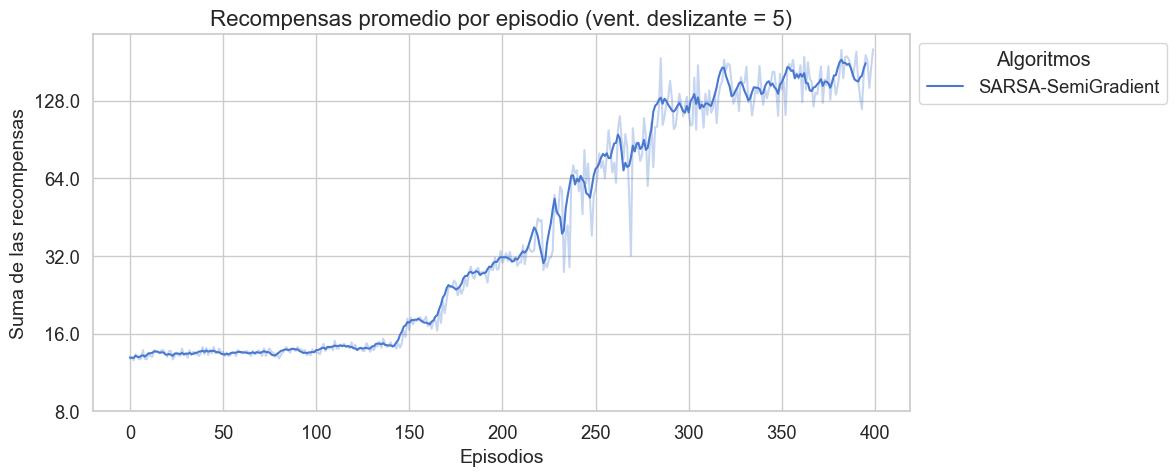

In [16]:
plotting.plot_rewards([rewards_sarsasemigradient],
                      ["SARSA-SemiGradient"],
                      log_scale=True,
                      rolling_window=5)

In [17]:
print("Media de las recompensas de los últimos 50 episodios:")
print("sarsa semigradient:", rewards_sarsasemigradient[-50:].mean())
print("deepqlearning:", rewards_deepqlearning[-50:].mean())
print("doubledeepqlearning:", rewards_doubledeepqlearning[-50:].mean())

Media de las recompensas de los últimos 50 episodios:
sarsa semigradient: 159.80599999999998
deepqlearning: 246.56800000000004
doubledeepqlearning: 178.26400000000004


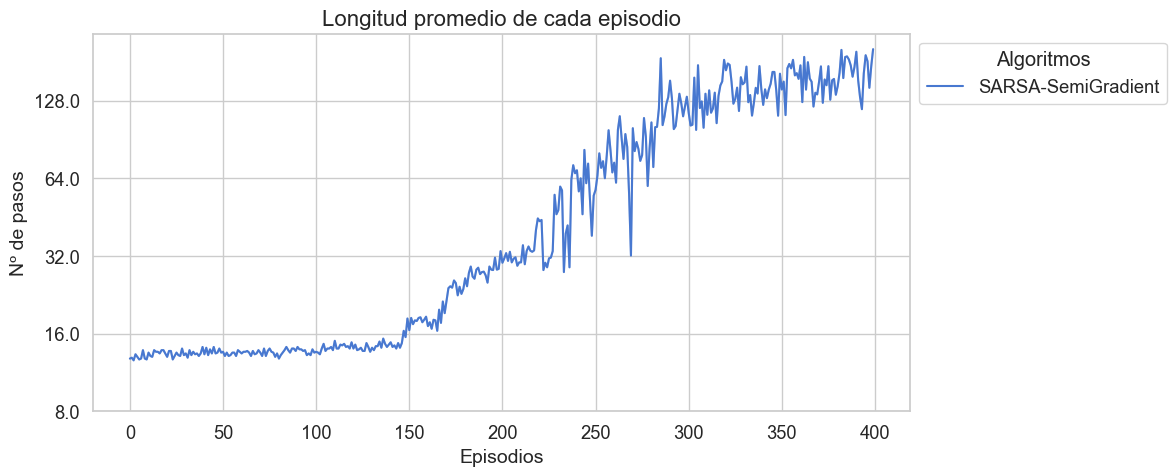

In [18]:
plotting.plot_episode_lengths([episode_lengths_sarsasemigradient],
                                ["SARSA-SemiGradient"],
                                log_scale=True,
                                rolling_window=1)

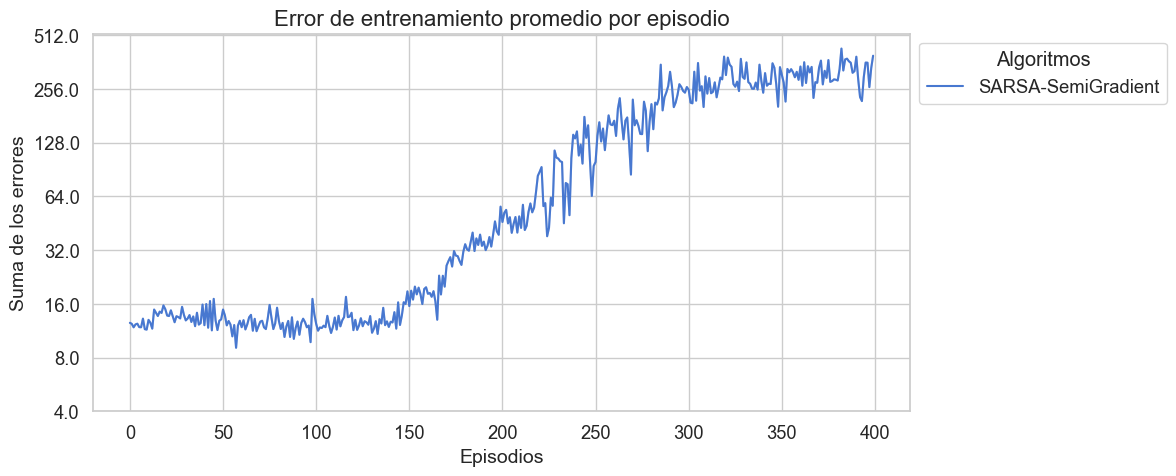

In [19]:
plotting.plot_training_errors([stats_sarsasemigradient['cum_training_error']],
                                ["SARSA-SemiGradient"],
                                log_scale=True,
                                rolling_window=1)

In [21]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
base_env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n=4)
frames = run_episode_greedy(base_env, learner_sarsasemigradient, max_steps=1000)
base_env.close()
gif_path = frames_to_gif(frames, filename="cartpole_sarsasemigradient.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_sarsasemigradient.gif


### Algoritmos Deep Q

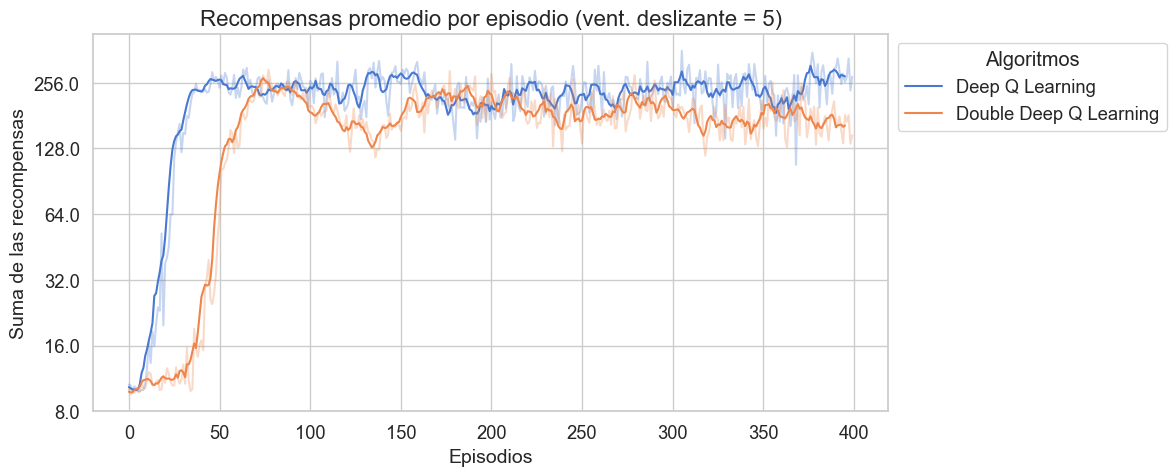

In [22]:
plotting.plot_rewards([rewards_deepqlearning, rewards_doubledeepqlearning],
                      ["Deep Q Learning", "Double Deep Q Learning"],
                      log_scale=True,
                      rolling_window=5)

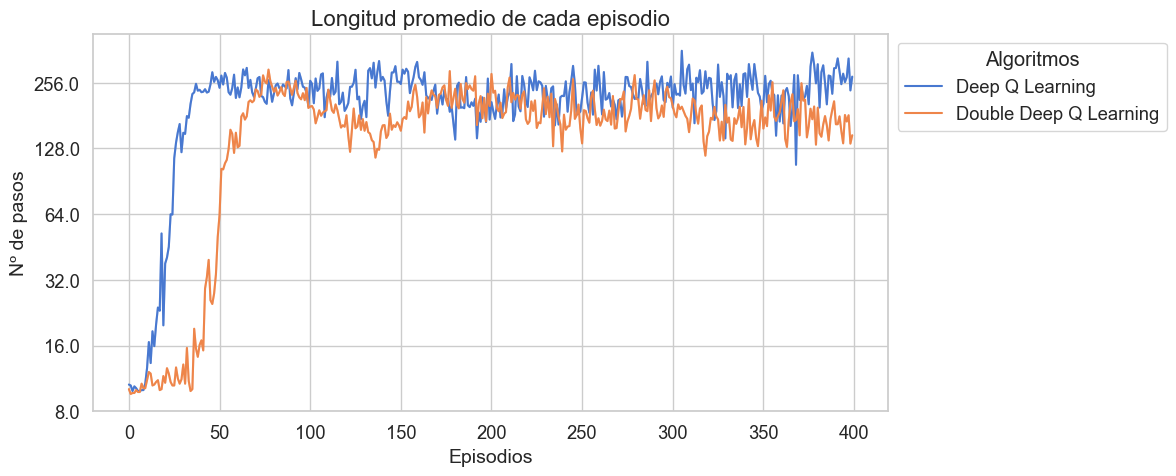

In [23]:
plotting.plot_episode_lengths([episode_lengths_deepqlearning, episode_lengths_doubledeepqlearning],
                                ["Deep Q Learning", "Double Deep Q Learning"],
                                log_scale=True,
                                rolling_window=1)

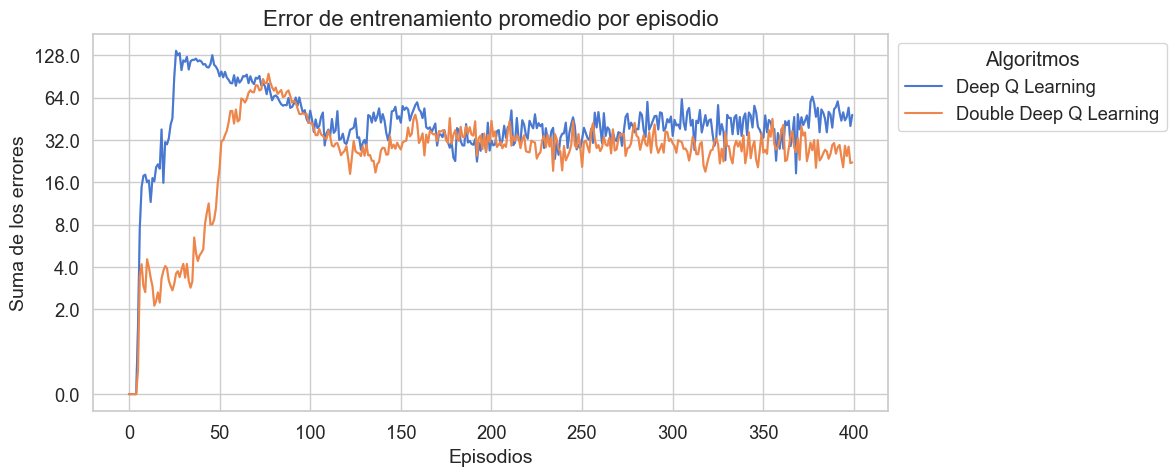

In [24]:
plotting.plot_training_errors([stats_deepqlearning['cum_training_error'], stats_doubledeepqlearning['cum_training_error']],
                                ["Deep Q Learning", "Double Deep Q Learning"],
                                log_scale=True,
                                rolling_window=1)

In [25]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
frames = run_episode_greedy(base_env, learner_deepqlearning, max_steps=1000)
base_env.close()
gif_path = frames_to_gif(frames, filename="cartpole_deepqlearning.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_deepqlearning.gif


In [26]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
frames = run_episode_greedy(base_env, learner_doubledeepqlearning, max_steps=1000)
base_env.close()
gif_path = frames_to_gif(frames, filename="cartpole_doubledeepqlearning.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_doubledeepqlearning.gif
